# 01 — Data Exploration: APTOS 2019 Diabetic Retinopathy

**Goal:** Understand the dataset before building any model.

We will cover:
- Number of images
- Class distribution & imbalance
- Image sizes & resolutions
- Corrupted image detection
- Sample image visualization
---

## 1. Imports & Config

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# # ── Paths (adjust if your folder structure differs) ──────────────────────────
# BASE_DIR    = Path('../data/raw')
# IMG_DIR     = BASE_DIR / 'train_images'
# CSV_PATH    = BASE_DIR / 'train.csv'
# RESULTS_DIR = Path('../results')
# RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Paths — use .resolve() to convert to absolute paths ──────────────────────
BASE_DIR    = Path('../data/raw').resolve()   # ← add .resolve()
IMG_DIR     = BASE_DIR / 'train_images'
CSV_PATH    = BASE_DIR / 'train.csv'
RESULTS_DIR = Path('../results').resolve()    # ← add .resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Quick sanity check
print(f'IMG_DIR  : {IMG_DIR}')
print(f'Exists?  : {IMG_DIR.exists()}')
print(f'CSV_PATH : {CSV_PATH}')
print(f'Exists?  : {CSV_PATH.exists()}')

# ── Grade labels ─────────────────────────────────────────────────────────────
GRADE_LABELS = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative DR'
}

print('All imports successful')

IMG_DIR  : D:\projects\diabetic-retinopathy-detection\data\raw\train_images
Exists?  : True
CSV_PATH : D:\projects\diabetic-retinopathy-detection\data\raw\train.csv
Exists?  : True
All imports successful


---
## 2. Load the Dataset

In [14]:
df = pd.read_csv(CSV_PATH)

# Attach full image path
df['filepath'] = df['id_code'].apply(lambda x: IMG_DIR / f'{x}.png')

# Map numeric grade → label name
df['grade_label'] = df['diagnosis'].map(GRADE_LABELS)

print(f'Total samples : {len(df)}')
print(f'Columns       : {df.columns.tolist()}')
print()
df.head(10)

Total samples : 3662
Columns       : ['id_code', 'diagnosis', 'filepath', 'grade_label']



,id_code,diagnosis,filepath,grade_label
0,000c1434d8d7,2,D:\projects\diabetic-retinopathy-detection\dat...,Moderate
1,001639a390f0,4,D:\projects\diabetic-retinopathy-detection\dat...,Proliferative DR
2,0024cdab0c1e,1,D:\projects\diabetic-retinopathy-detection\dat...,Mild
3,002c21358ce6,0,D:\projects\diabetic-retinopathy-detection\dat...,No DR
4,005b95c28852,0,D:\projects\diabetic-retinopathy-detection\dat...,No DR
5,0083ee8054ee,4,D:\projects\diabetic-retinopathy-detection\dat...,Proliferative DR
6,0097f532ac9f,0,D:\projects\diabetic-retinopathy-detection\dat...,No DR
7,00a8624548a9,2,D:\projects\diabetic-retinopathy-detection\dat...,Moderate
8,00b74780d31d,2,D:\projects\diabetic-retinopathy-detection\dat...,Moderate
9,00cb6555d108,1,D:\projects\diabetic-retinopathy-detection\dat...,Mild


---
## 3. Class Distribution

In [15]:
class_counts = df['diagnosis'].value_counts().sort_index()
class_pct    = (class_counts / len(df) * 100).round(1)

summary = pd.DataFrame({
    'Grade' : [GRADE_LABELS[i] for i in class_counts.index],
    'Count' : class_counts.values,
    'Pct %' : class_pct.values
})
print(summary.to_string(index=False))

           Grade  Count  Pct %
           No DR   1805   49.3
            Mild    370   10.1
        Moderate    999   27.3
          Severe    193    5.3
Proliferative DR    295    8.1


Saved → D:\projects\diabetic-retinopathy-detection\results\class_distribution.png


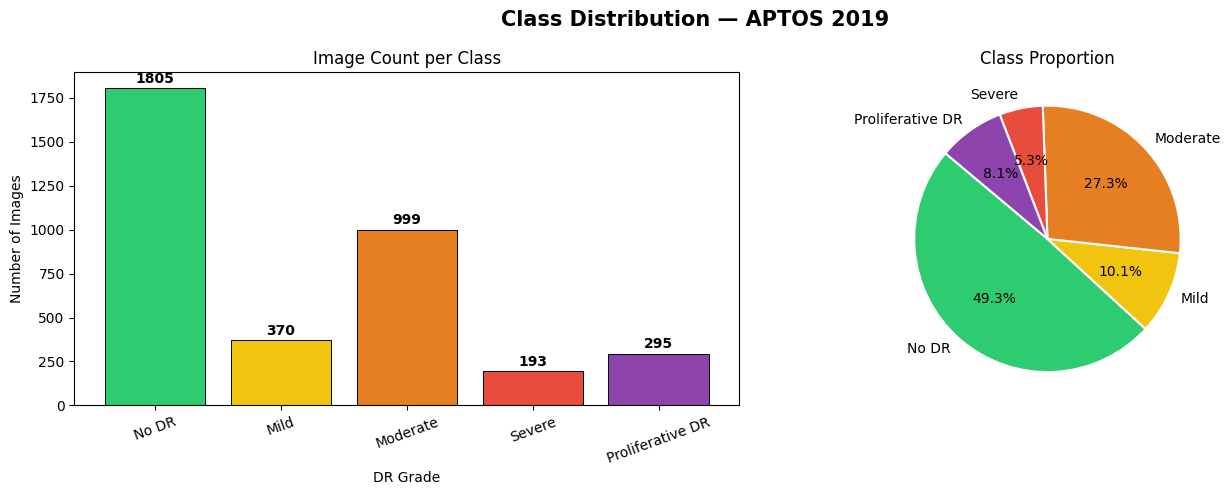

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — APTOS 2019', fontsize=15, fontweight='bold')

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
labels = [GRADE_LABELS[i] for i in range(5)]

# ── Bar chart ──────────────────────────────────────────────────────────────
bars = axes[0].bar(labels, class_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Image Count per Class')
axes[0].set_xlabel('DR Grade')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=20)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Pie chart ──────────────────────────────────────────────────────────────
axes[1].pie(
    class_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class Proportion')

plt.tight_layout()
save_path = RESULTS_DIR / 'class_distribution.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

---
## 4. Sample Images per Class

Saved → D:\projects\diabetic-retinopathy-detection\results\sample_images.png


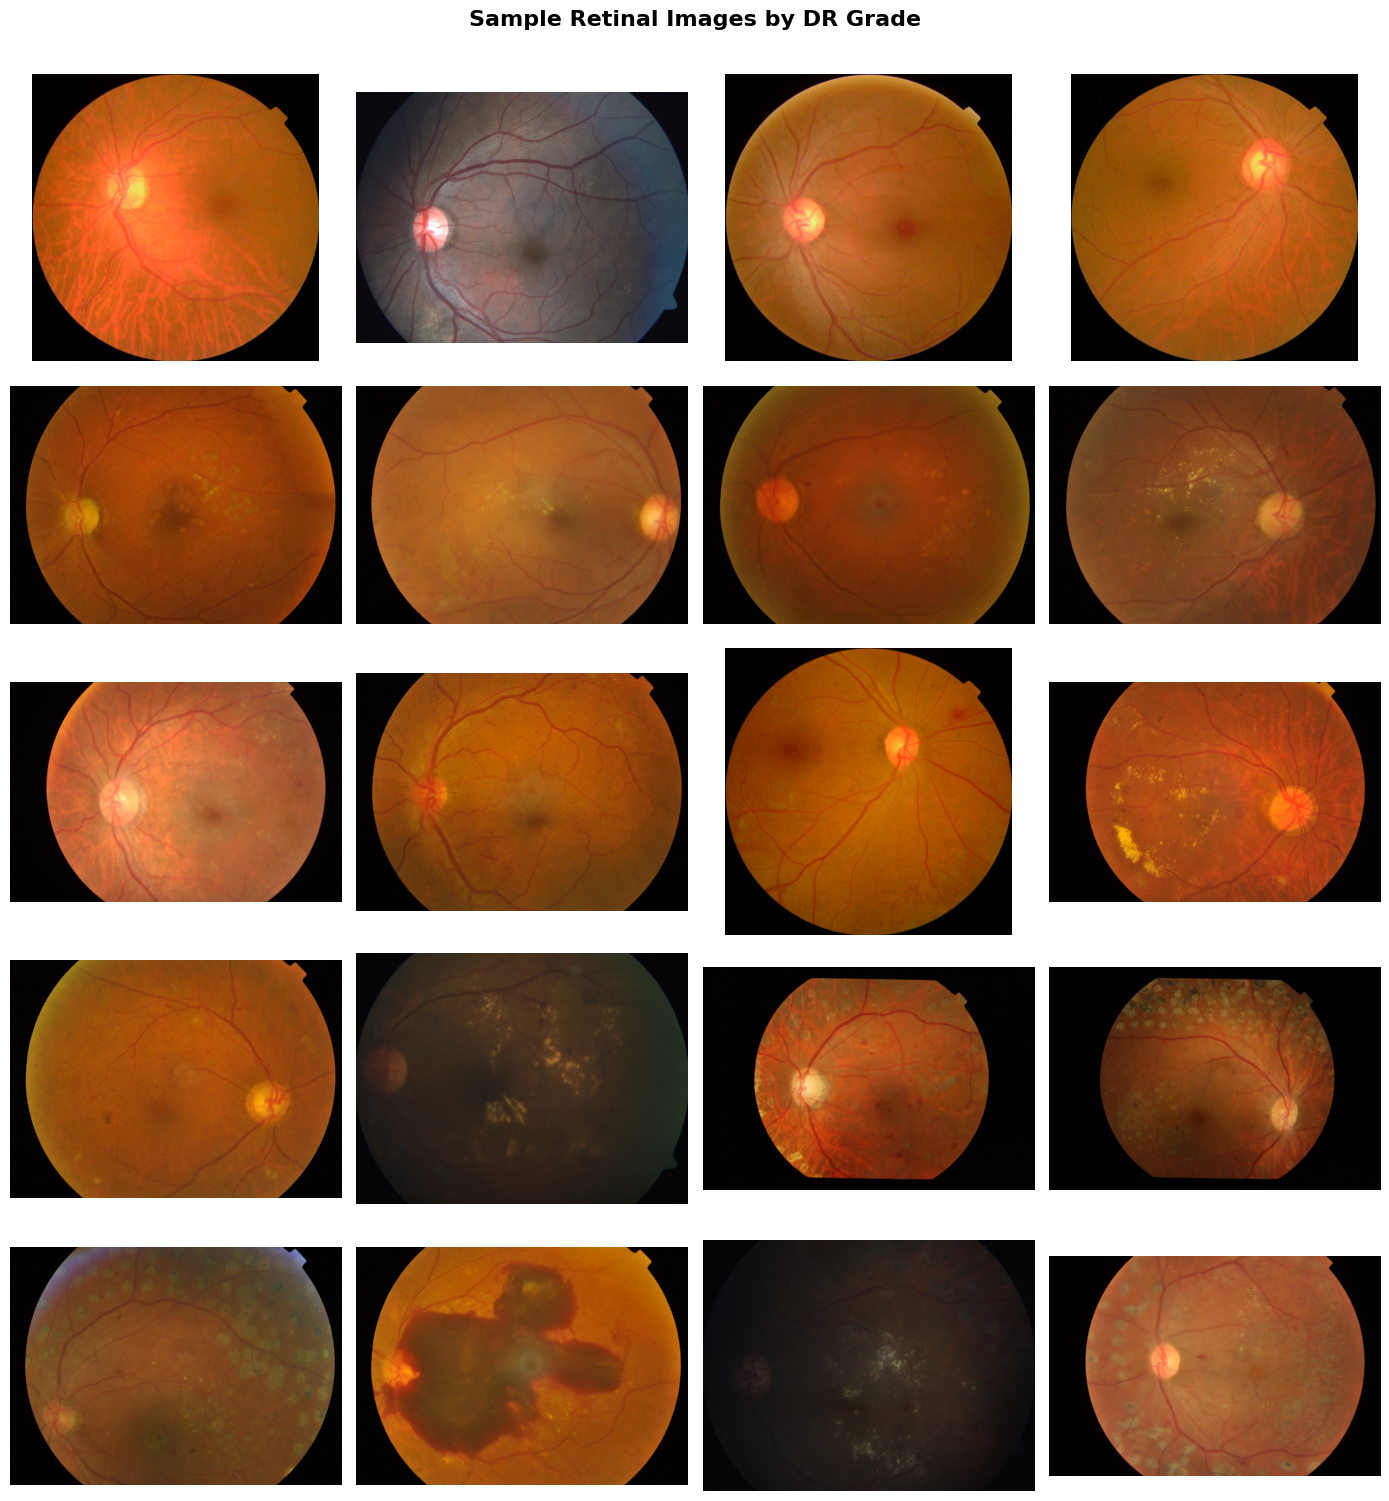

In [17]:
N_SAMPLES = 4

fig, axes = plt.subplots(5, N_SAMPLES, figsize=(N_SAMPLES * 3.5, 5 * 3))
fig.suptitle('Sample Retinal Images by DR Grade', fontsize=16, fontweight='bold', y=1.01)

for grade in range(5):
    samples = df[df['diagnosis'] == grade].sample(N_SAMPLES, random_state=42)
    for col, (_, row) in enumerate(samples.iterrows()):
        ax = axes[grade][col]
        try:
            img = Image.open(str(row['filepath'])).convert('RGB')  # ← force RGB, str path
            ax.imshow(np.array(img))                               # ← convert to numpy array
        except Exception as e:
            ax.text(0.5, 0.5, f'Error:\n{e}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=7, color='red')  # ← show actual error
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'Grade {grade}\n{GRADE_LABELS[grade]}',
                          fontsize=11, fontweight='bold', rotation=0,
                          labelpad=60, va='center')                # ← use ylabel instead of title

plt.tight_layout()
save_path = RESULTS_DIR / 'sample_images.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

---
## 5. Image Size & Resolution Analysis

In [19]:
print('Scanning image resolutions (this may take a minute)...')

widths, heights, modes = [], [], []

for fp in tqdm(df['filepath']):
    try:
        with Image.open(fp) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
    except Exception:
        widths.append(None)
        heights.append(None)
        modes.append('ERROR')

df['width']  = widths
df['height'] = heights
df['mode']   = modes

valid = df[df['width'].notna()]
print(f'\nWidth  — min: {valid.width.min()}, max: {valid.width.max()}, mean: {valid.width.mean():.0f}')
print(f'Height — min: {valid.height.min()}, max: {valid.height.max()}, mean: {valid.height.mean():.0f}')
print(f'\nUnique image modes: {df["mode"].unique()}')
print(f'Unique resolutions : {valid.groupby(["width","height"]).size().shape[0]} distinct sizes')

Scanning image resolutions (this may take a minute)...


100%|████████████████████████████████████████████████████████████████████████████| 3662/3662 [00:00<00:00, 5976.19it/s]


Width  — min: 474, max: 4288, mean: 2015
Height — min: 358, max: 2848, mean: 1527

Unique image modes: ['RGB']
Unique resolutions : 17 distinct sizes


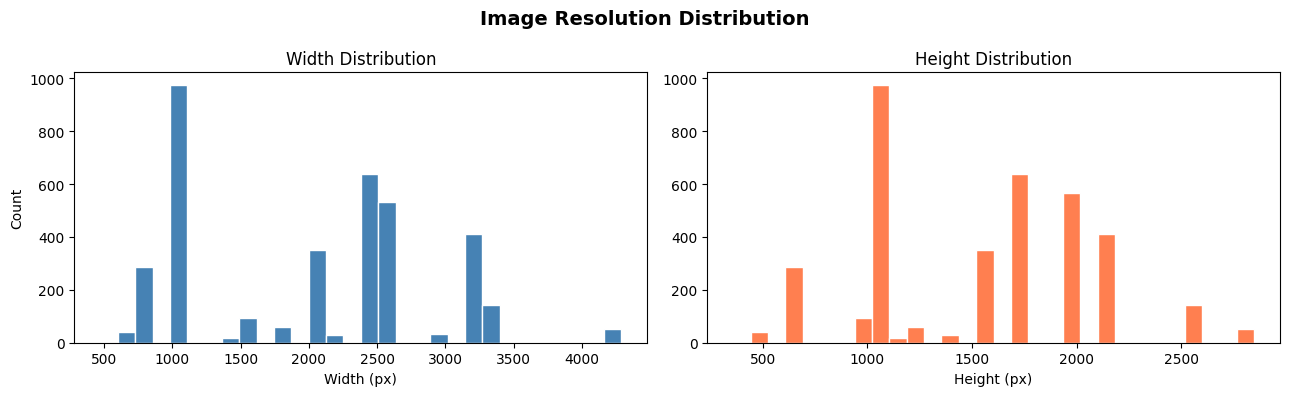

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Image Resolution Distribution', fontsize=14, fontweight='bold')

axes[0].hist(valid['width'],  bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')

axes[1].hist(valid['height'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (px)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'resolution_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Corrupted Image Detection

In [ ]:
# ── Run once to verify dataset integrity — takes ~3 mins ──────────────────
print('Checking for corrupted images...')

corrupted = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        img = Image.open(row['filepath'])
        img.verify()          # catches truncated / invalid files
    except (UnidentifiedImageError, Exception) as e:
        corrupted.append({'id_code': row['id_code'], 'error': str(e)})

if corrupted:
    print(f'\n⚠️  Found {len(corrupted)} corrupted file(s):')
    for c in corrupted:
        print(f"  {c['id_code']} → {c['error']}")
else:
    print('\n✅ No corrupted images found!')

# Save corrupted list for preprocessing reference
corrupted_df = pd.DataFrame(corrupted)
if not corrupted_df.empty:
    corrupted_df.to_csv(RESULTS_DIR / 'corrupted_images.csv', index=False)
    print(f'Saved corrupted list → {RESULTS_DIR}/corrupted_images.csv')

Checking for corrupted images...


NameError: name 'tqdm' is not defined

---
## 7. Class Imbalance Analysis

In [23]:
majority = class_counts.max()
print('Imbalance ratios (majority class / class count):\n')
for grade, count in class_counts.items():
    ratio = majority / count
    bar   = '█' * int(ratio * 3)
    print(f'  Grade {grade} ({GRADE_LABELS[grade]:<18}) | {count:>4} images | ratio {ratio:>5.1f}x  {bar}')

print()
print('💡 Strategy: Use weighted loss or oversampling for minority classes (grades 1, 3, 4)')

Imbalance ratios (majority class / class count):

  Grade 0 (No DR             ) | 1805 images | ratio   1.0x  ███
  Grade 1 (Mild              ) |  370 images | ratio   4.9x  ██████████████
  Grade 2 (Moderate          ) |  999 images | ratio   1.8x  █████
  Grade 3 (Severe            ) |  193 images | ratio   9.4x  ████████████████████████████
  Grade 4 (Proliferative DR  ) |  295 images | ratio   6.1x  ██████████████████

💡 Strategy: Use weighted loss or oversampling for minority classes (grades 1, 3, 4)


In [25]:
# Compute class weights for training (save for use in train.py)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1,2,3,4]),
    y=df['diagnosis'].values
)
weight_dict = {i: w for i, w in enumerate(class_weights)}

print('Class weights for loss function:')
for grade, weight in weight_dict.items():
    print(f'  Grade {grade} ({GRADE_LABELS[grade]:<18}): {weight:.4f}')

# Save for later use in train.py
import json
with open(RESULTS_DIR / 'class_weights.json', 'w') as f:
    json.dump(weight_dict, f, indent=2)
print(f'\nSaved → {RESULTS_DIR}/class_weights.json')

Class weights for loss function:
  Grade 0 (No DR             ): 0.4058
  Grade 1 (Mild              ): 1.9795
  Grade 2 (Moderate          ): 0.7331
  Grade 3 (Severe            ): 3.7948
  Grade 4 (Proliferative DR  ): 2.4827

Saved → D:\projects\diabetic-retinopathy-detection\results/class_weights.json


---
## 8. Summary

In [1]:
print('=' * 50)
print('  DATASET SUMMARY')
print('=' * 50)
print(f'  Total images       : {len(df)}')
print(f'  Corrupted images   : {len(corrupted)}')
print(f'  Usable images      : {len(df) - len(corrupted)}')
print(f'  Unique resolutions : {valid.groupby(["width","height"]).size().shape[0]}')
print(f'  Image modes        : {df["mode"].unique().tolist()}')
print()
print('  Class breakdown:')
for grade, count in class_counts.items():
    print(f'    Grade {grade} ({GRADE_LABELS[grade]:<18}): {count} ({count/len(df)*100:.1f}%)')
print()
print('  Saved outputs in results/:')
print('    class_distribution.png')
print('    sample_images.png')
print('    resolution_distribution.png')
print('    class_weights.json')
print('=' * 50)
print('  Ready for preprocessing → 02 notebook')
print('=' * 50)

  DATASET SUMMARY


NameError: name 'df' is not defined